In [1]:
import pandas as pd
import os

# Diretório onde estão os arquivos CSV
caminho_diretorio = "data/csv_format/"
arquivos_csv = [f for f in os.listdir(caminho_diretorio) if f.endswith(".csv")]
dfs = [pd.read_csv(os.path.join(caminho_diretorio, arquivo), delimiter=',', dtype=str).assign(arquivo=arquivo) for arquivo in arquivos_csv]
df_final = pd.concat(dfs, ignore_index=True)
df_final.head()


,Unnamed: 0,TP_NOT,ID_AGRAVO,DT_NOTIFIC,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,DT_DIAG,ANO_NASC,...,AGRAVDROGA,AGRAVTABAC,TEST_MOLEC,TEST_SENSI,ANT_RETRO,BAC_APOS_6,TRANSF,UF_TRANSF,MUN_TRANSF,arquivo
0,0,2,A169,2001-01-04,2001,41,410420,1356,2001-01-04,1961,...,0,0,0,0,0,0,0,NaN,NaN,TUBEBR01.csv
1,1,2,A169,2001-02-20,2001,41,410690,1356,2001-02-20,1974,...,0,0,0,0,0,0,0,NaN,NaN,TUBEBR01.csv
2,2,2,A169,2001-01-12,2001,26,260570,1506,2001-01-12,1960,...,0,0,0,0,0,0,0,NaN,NaN,TUBEBR01.csv
3,3,2,A169,2001-02-23,2001,15,150140,1484,2001-02-23,1975,...,0,0,0,0,0,0,0,NaN,NaN,TUBEBR01.csv
4,4,2,A169,2001-01-05,2001,13,130120,0,2001-01-05,1975,...,0,0,0,0,0,0,0,NaN,NaN,TUBEBR01.csv


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_histograma(dados, titulo='Histograma', xlabel='Valores', ylabel='Frequência'):
    plt.figure(figsize=(8, 5))
    plt.hist(dados, edgecolor='black', color='skyblue')
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [3]:
df_final['NU_ANO'] = pd.to_numeric(df_final['NU_ANO'], errors='coerce')
df_final_filtrado_ano = df_final[df_final['NU_ANO'].between(2019, 2025)]

df_final_filtrado_ano.shape

(506195, 99)

In [5]:
df_final_filtrado_ano.columns

Index(['Unnamed: 0', 'TP_NOT', 'ID_AGRAVO', 'DT_NOTIFIC', 'NU_ANO',
       'SG_UF_NOT', 'ID_MUNICIP', 'ID_REGIONA', 'DT_DIAG', 'ANO_NASC',
       'NU_IDADE_N', 'CS_SEXO', 'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'SG_UF',
       'ID_MN_RESI', 'ID_RG_RESI', 'ID_PAIS', 'NDUPLIC_N', 'IN_VINCULA',
       'DT_DIGITA', 'DT_TRANSUS', 'DT_TRANSDM', 'DT_TRANSSM', 'DT_TRANSRM',
       'DT_TRANSRS', 'DT_TRANSSE', 'CS_FLXRET', 'FLXRECEBI', 'MIGRADO_W',
       'ID_OCUPA_N', 'TRATAMENTO', 'INSTITUCIO', 'RAIOX_TORA', 'TESTE_TUBE',
       'FORMA', 'EXTRAPU1_N', 'EXTRAPU2_N', 'EXTRAPUL_O', 'AGRAVAIDS',
       'AGRAVALCOO', 'AGRAVDIABE', 'AGRAVDOENC', 'AGRAVOUTRA', 'AGRAVOUTDE',
       'BACILOSC_E', 'BACILOS_E2', 'BACILOSC_O', 'CULTURA_ES', 'CULTURA_OU',
       'HIV', 'HISTOPATOL', 'DT_INIC_TR', 'RIFAMPICIN', 'ISONIAZIDA',
       'ETAMBUTOL', 'ESTREPTOMI', 'PIRAZINAMI', 'ETIONAMIDA', 'OUTRAS',
       'OUTRAS_DES', 'TRAT_SUPER', 'NU_CONTATO', 'DOENCA_TRA', 'SG_UF_AT',
       'ID_MUNIC_A', 'DT_NOTI_AT', 'SG_

O campo a seguir que sinaliza se houve óbito ou cura:

### 🔹 `SITUA_ENCE` — Situação de encerramento

Conforme o dicionário de dados do SINAN para tuberculose:

| Valor | Descrição                         | 
|-------|-----------------------------------|
| 1     | Cura                              |
| 2     | Abandono                          |
| 3     | Óbito por Tuberculose             |
| 4     | Óbito por outras causas           |
| 5     | Transferência                     |
| 6     | Mudança de diagnóstico            |
| 7     | TB resistente (TB-DR)             |
| 8     | Mudança de esquema terapêutico    |
| 9     | Falência                          |
| 10    | Abandono primário                 |

In [24]:
df_final_filtrado_ano['SITUA_ENCE'].value_counts()


SITUA_ENCE
 1    298620
 2     73360
 5     35303
 4     20546
 3     20026
 6     10555
 7      5321
10      5038
 8      4341
1       1836
2        853
 9       336
5        294
3        180
4        140
7        102
0         36
03        35
8         27
04        13
9          7
-1         1
Name: count, dtype: int64

In [25]:
def agrupar_situacao(codigo):
    try:
        if pd.isna(codigo):
            return 0
        codigo = int(float(codigo))  # converte para int, mesmo que venha como float tipo 1.0
        if codigo == 1:
            return 1
        elif codigo == 2:
            return 2
        else:
            return 0
    except:
        print(f'Erro ao processar: {codigo}')
        return 'Outro'


df_final_filtrado_ano.loc[:, 'SITUACAO_AGRUPADA'] = df_final_filtrado_ano['SITUA_ENCE'].apply(agrupar_situacao)


In [22]:
df_final_filtrado_ano['SITUACAO_AGRUPADA'].value_counts()

SITUACAO_AGRUPADA
1    300456
0    131526
2     74213
Name: count, dtype: int64

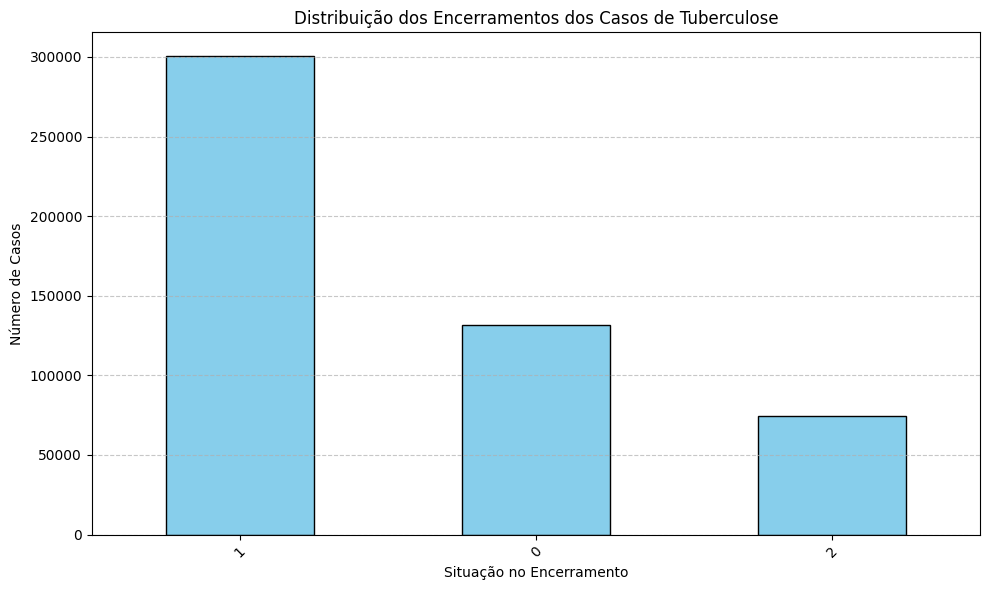

In [26]:
import matplotlib.pyplot as plt

# Conta os valores
contagem = df_final_filtrado_ano['SITUACAO_AGRUPADA'].value_counts()

# Plota
plt.figure(figsize=(10, 6))
contagem.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Distribuição dos Encerramentos dos Casos de Tuberculose')
plt.xlabel('Situação no Encerramento')
plt.ylabel('Número de Casos')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [27]:
df_sem_zero = df_final_filtrado_ano[df_final_filtrado_ano['SITUA_ENCE'] != 0]

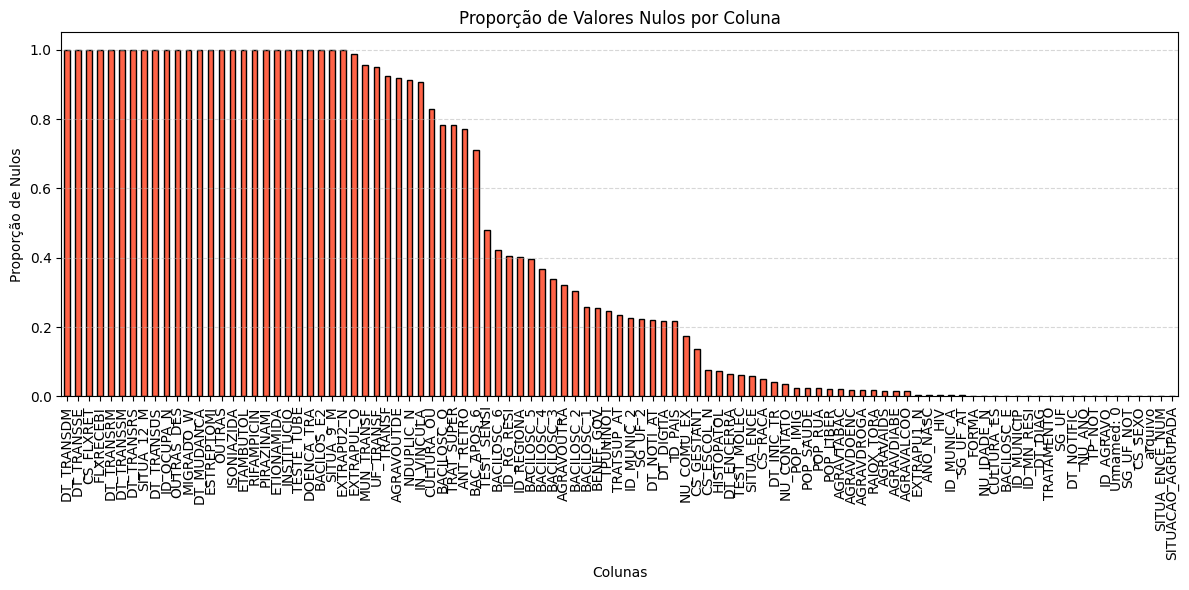

In [ ]:
# a gente tentou cortar as colunas com mais componentes nulos

import matplotlib.pyplot as plt

# Calcula a proporção de valores nulos por coluna
null_ratios = df_sem_zero.isna().mean()

# Plota o histograma (gráfico de barras)
plt.figure(figsize=(12, 6))
null_ratios.sort_values(ascending=False).plot(kind='bar', color='tomato', edgecolor='black')

plt.title('Proporção de Valores Nulos por Coluna')
plt.xlabel('Colunas')
plt.ylabel('Proporção de Nulos')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [32]:
# Define the threshold (e.g., 50% empty values)
threshold = 0.6

# Calculate the proportion of empty (or NaN) values per column
empty_ratio = df_sem_zero.isna().mean()

# Select columns where the proportion of empty values exceeds the threshold
columns_to_drop = empty_ratio[empty_ratio > threshold].index

# Drop those columns
df_sem_zero_cleaned = df_sem_zero.copy()
df_sem_zero_cleaned = df_sem_zero_cleaned.drop(columns=columns_to_drop)

# Display the cleaned dataframe
df_sem_zero_cleaned.head()

,Unnamed: 0,TP_NOT,ID_AGRAVO,DT_NOTIFIC,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,DT_DIAG,ANO_NASC,...,POP_SAUDE,POP_IMIG,BENEF_GOV,AGRAVDROGA,AGRAVTABAC,TEST_MOLEC,TEST_SENSI,arquivo,SITUA_ENCE_NUM,SITUACAO_AGRUPADA
180124,92859,2,A169,2020-03-18,2020,35,355030,0,2002-02-10,1964,...,2,2,0,1,2,5,7,TUBEBR02.csv,0,1
715334,86768,2,A169,2019-10-02,2019,35,355030,0,2008-10-01,1962,...,2,2,0,2,1,1,5,TUBEBR08.csv,0,1
801654,86319,2,A169,2019-01-02,2019,35,355030,0,2009-12-27,1970,...,2,2,0,2,1,1,7,TUBEBR09.csv,0,0
801655,86320,2,A169,2020-05-26,2020,35,355030,0,2009-06-15,1982,...,2,3,0,2,2,1,7,TUBEBR09.csv,0,1
887037,85381,2,A169,2019-04-18,2019,35,355030,0,2010-08-19,1983,...,2,2,0,1,1,1,5,TUBEBR10.csv,0,1


In [ ]:
df_sem_zero_cleaned['ID_AGRAVO'].value_counts()


ID_AGRAVO
A169    506190
A16.         4
A144         1
Name: count, dtype: int64

In [39]:
df_sem_zero_cleaned['ID_MUNICIP'].value_counts()


ID_MUNICIP
330455    45300
355030    42878
130260    17011
261160    15327
431490    11801
          ...  
430461        1
430430        1
431407        1
430957        1
316230        1
Name: count, Length: 5182, dtype: int64

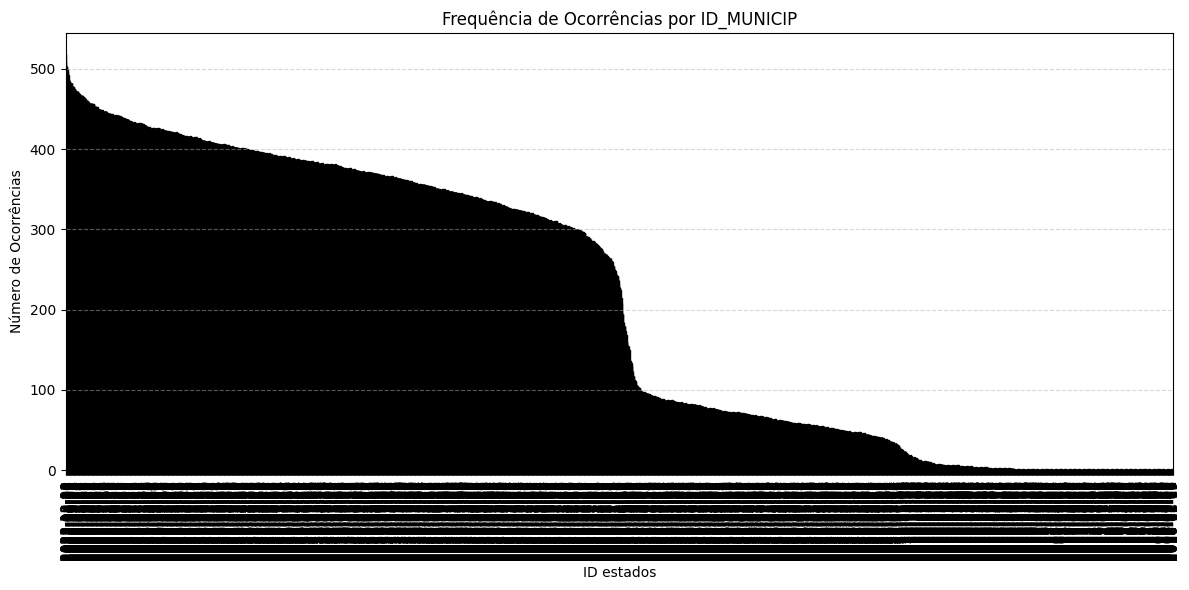

In [43]:
import matplotlib.pyplot as plt

# Conta as ocorrências por ID
contagem_ids = df_sem_zero_cleaned['DT_DIAG'].value_counts()

# Plota o gráfico de barras
plt.figure(figsize=(12, 6))
contagem_ids.plot(kind='bar', color='cornflowerblue', edgecolor='black')

plt.title('Frequência de Ocorrências por ID_MUNICIP')
plt.xlabel('ID estados')
plt.ylabel('Número de Ocorrências')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


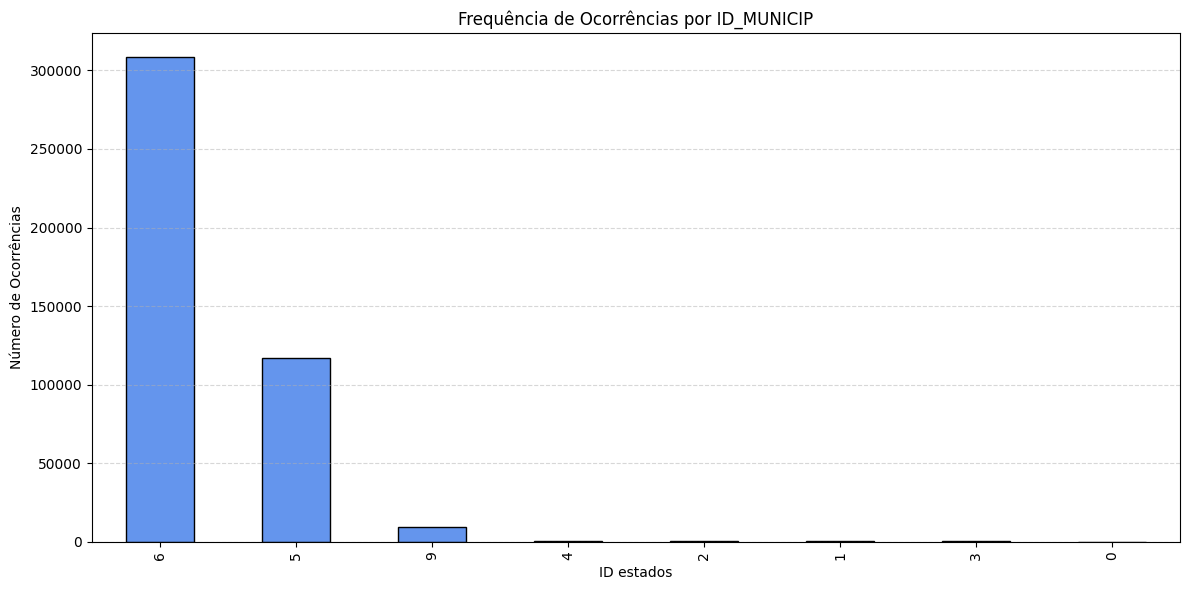

In [45]:
import matplotlib.pyplot as plt

# Conta as ocorrências por ID
contagem_ids = df_sem_zero_cleaned['CS_GESTANT'].value_counts()

# Plota o gráfico de barras
plt.figure(figsize=(12, 6))
contagem_ids.plot(kind='bar', color='cornflowerblue', edgecolor='black')

plt.title('Frequência de Ocorrências por ID_MUNICIP')
plt.xlabel('ID estados')
plt.ylabel('Número de Ocorrências')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [33]:
df_sem_zero_cleaned.columns

Index(['Unnamed: 0', 'TP_NOT', 'ID_AGRAVO', 'DT_NOTIFIC', 'NU_ANO',
       'SG_UF_NOT', 'ID_MUNICIP', 'ID_REGIONA', 'DT_DIAG', 'ANO_NASC',
       'NU_IDADE_N', 'CS_SEXO', 'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'SG_UF',
       'ID_MN_RESI', 'ID_RG_RESI', 'ID_PAIS', 'DT_DIGITA', 'TRATAMENTO',
       'RAIOX_TORA', 'FORMA', 'EXTRAPU1_N', 'AGRAVAIDS', 'AGRAVALCOO',
       'AGRAVDIABE', 'AGRAVDOENC', 'AGRAVOUTRA', 'BACILOSC_E', 'CULTURA_ES',
       'HIV', 'HISTOPATOL', 'DT_INIC_TR', 'NU_CONTATO', 'SG_UF_AT',
       'ID_MUNIC_A', 'DT_NOTI_AT', 'SG_UF_2', 'ID_MUNIC_2', 'BACILOSC_1',
       'BACILOSC_2', 'BACILOSC_3', 'BACILOSC_4', 'BACILOSC_5', 'BACILOSC_6',
       'TRATSUP_AT', 'NU_COMU_EX', 'SITUA_ENCE', 'DT_ENCERRA', 'TPUNINOT',
       'POP_LIBER', 'POP_RUA', 'POP_SAUDE', 'POP_IMIG', 'BENEF_GOV',
       'AGRAVDROGA', 'AGRAVTABAC', 'TEST_MOLEC', 'TEST_SENSI', 'arquivo',
       'SITUA_ENCE_NUM', 'SITUACAO_AGRUPADA'],
      dtype='object')